# Examples of Alen-Cahn equation discovery with EPDE framework

This notebook presents an overview of the evolutionary discovery of the burgers equation with the EPDE framework.

In [2]:
import numpy as np
import pandas as pd
import os
import sys
from typing import Union, Callable


import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D 

Add some necessary imports

In [3]:
import sys
sys.path.append('..')

import epde
from epde.interface.interface import EpdeSearch
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['text.usetex'] = False

SMALL_SIZE = 12
mpl.rc('font', size=SMALL_SIZE)
mpl.rc('axes', titlesize=SMALL_SIZE)

# Allen–Cahn equation introduction.

Allen–Cahn equation — a compact reaction-diffusion model describing the motion of phase boundaries during phase separation, combining diffusive smoothing and nonlinear phase-selection in a single partial differential equation:

$$
\frac{\partial u}{\partial t} = \varepsilon \frac{\partial^2 u}{\partial x^2} + u - u^3
$$

where:

- $u(x, t)$ — the unknown field (the order parameter, indicating which of two stable phases the material is in at position $x$ and time $t$, with $u \approx +1$ and $u \approx -1$ corresponding to the two phases);
- $t$ — time;
- $x$ — spatial coordinate;
- $\varepsilon$ — the diffusion (interface-width) parameter, controlling how sharp or diffuse the transition zone between the two phases is.

**Where it comes from.** The equation was introduced by Samuel Allen and John W. Cahn in 1979 to model the motion of antiphase boundaries in crystalline solids. It is widely used as a benchmark reaction-diffusion system due to its simple structure combining linear diffusion with a nonlinear double-well reaction term, and it appears throughout materials science, image processing, and phase-field modeling.

**Example solution.** Unlike the Aizawa system, this equation does admit a known closed-form solution for the important special case of a stationary planar interface. Seeking a solution independent of time and solving the resulting ODE yields a smooth transition (kink) profile between the two stable phases:

$$
u(x, t) = \tanh\left(\frac{x}{\sqrt{2\varepsilon}}\right)
$$

The profile is a smooth S-shaped front connecting $u=-1$ and $u=+1$, remaining stationary in 1D — a stationary balance between nonlinear phase-separation and diffusive smoothing.

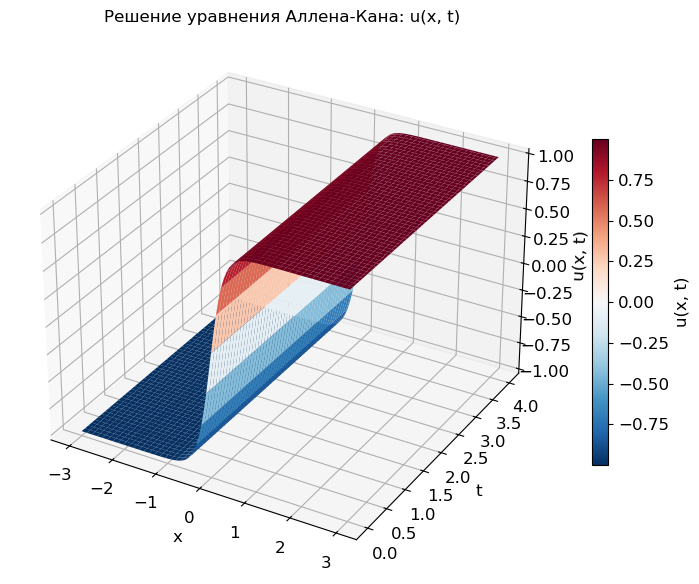

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # нужен для projection='3d'

eps = 0.05

t = np.linspace(0, 4, 100)
x = np.linspace(-3, 3, 100)
T, X = np.meshgrid(t, x, indexing='ij')

U = np.tanh(X / np.sqrt(2 * eps))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, T, U, cmap='RdBu_r', edgecolor='none', antialiased=True)

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('u(x, t)')
ax.set_title('Решение уравнения Аллена-Кана: u(x, t)')
fig.colorbar(surf, shrink=0.6, label='u(x, t)')
fig.tight_layout()
plt.show()

Reading target variable from file and create grid:

In [6]:
t = np.linspace(0., 1., 51)
x = np.linspace(-1., 0.984375, 128)
data = np.load("../projects/pic/data/ac/ac_data.npy")
    # t = np.linspace(0, 1, shape+1); x = np.linspace(0, 1, shape+1)
grid = np.meshgrid(t, x, indexing = 'ij')  # np.stack(, axis = 2) , axis = 2)


In [ ]:
epde_search_obj = EpdeSearch(use_solver=False, multiobjective_mode=True,
                             use_pic=True, boundary=(5, 10), verbose_params = {'show_iter_idx' : True, 'show_iter_fitness' : True},
                             coordinate_tensors=grid, device='cpu')


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000232E1095E80>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000232E1095E80>


Here you can see the explanation of each parametr in EpdeSearch creation:
   -  ``use_solver = False`` — skip the automatic PDE solver when scoring candidate equations; faster, less precise fitness estimate
   - ``multiobjective_mode = True`` — run MOEADD multi-objective search: Pareto front by Discrepancy (quality) + Instability
   - ``use_pic = True`` — define second pareto axis = Instability
   - ``boundary = (5, 10)`` — ignore this many grid points  in axes from each edge of the domain when computing derivatives
   - ``coordinate_tensors = grid`` — grid coordinate tensors (from np.meshgrid) matching the data array
   - ``device = 'cpu'`` — device for torch computations

In [ ]:
epde_search_obj.set_preprocessor(default_preprocessor_type='poly',
                                     preprocessor_kwargs={})
popsize = 8
epde_search_obj.set_moeadd_params(population_size=popsize,
                                      training_epochs=4)

In the cell above we define data preprocessor settings( derivatives computation with polynomial smoothing).
Additional parameters will be population size and number of optimziation epochs: ``training_epochs = 4``.

In [12]:
factors_max_number = {'factors_num': [1, 2], 'probas': [0.65, 0.35]}


epde_search_obj.fit(data= data, variable_names=['u', ], max_deriv_order=(2, 3), derivs=None,
                    equation_terms_max_number=5, data_fun_pow=3,
                    additional_tokens=[],
                    equation_factors_max_number=factors_max_number,
                    fourier_layers=False) #, data_nn=data_nn


self.vars_demand_equation {'u'}
best_obj 2

========== Initial population ==========
[ 0.96912565 21.30630693]
[ 0.83159507 28.04297853]
[0.92364472 2.67503683]
[ 0.7350575  27.23437925]
[0.89942884 8.82462277]
[0.0226214  0.00731387]
[0.96301368 0.15766542]
[0.00259316 0.01537421]

========== Marriage (weight assignment) ==========
acute_angles
 [[0.04545406 0.02964562 0.33246642 0.02698351 0.10157189 1.25808794
  1.40851521 0.16709672]
 [0.11969462 0.13550306 0.16731774 0.13816517 0.06357679 1.09293927
  1.24336653 0.00194804]
 [0.33505232 0.35086076 0.04803996 0.35352287 0.27893449 0.87758157
  1.02800883 0.21340966]
 [0.59804705 0.61385549 0.31103469 0.6165176  0.54192922 0.61458684
  0.7650141  0.47640439]
 [0.88184116 0.8976496  0.5948288  0.90031171 0.82572333 0.33079273
  0.48121999 0.7601985 ]
 [1.14483589 1.16064433 0.85782353 1.16330644 1.08871806 0.06779799
  0.21822526 1.02319323]
 [1.36019359 1.37600203 1.07318123 1.37866414 1.30407576 0.1475597
  0.00286756 1.23855093]
 

Here you can see the explanation of parametrs parametr in fit method:
 - argument ``data`` desctibes array of target variable(u)
 - argument ``variable_names`` sets name of target variable
 - argument ``max_deriv_order`` sets the highest order of derivatives, that can be used in equation search
- number of terms, accepted into the structure before regularization is regulated by argument ``equation_terms_max_number``
- argument ``equation_factors_max_number`` defines number of terms in the term can be set as integer (in this case, one number factor will apear in equation with 0.65 probability and two number factor appear with 0.35 probability)
- argeument ``derives = None``  means that algorithm calculates derivatives in the method, skips pre-computed values 
- argument ``additional_tokens`` sets tokens, hat would be used to construct the equations among the main variables and their derivatives
- argument ``data_fun_pow`` describes maximum power of token
- parametr ``fourier_layer`` controls whether the data-representation ANN used for solver-based fitness

The discovered equations can be accessed with ``EpdeSearch.equations()`` method. If the ``only_print = True``, than the equations will be printed in their text forms. 

Otherwise, they will be return: if the followup argument ``only_str`` is ``True``, than the equations are returned only in their symbolic string-form. If ``only_str = False``, than the equation in its program implementation ``epde.structure.main_structures.SoEq`` are returned.

Additional parametr ``num = 3`` define number of poretto-levels for printing

In [ ]:
epde_search_obj.equations(only_print=True, num = 5)